# Credit Scoring – Exploratory Data Analysis

This notebook performs a comprehensive exploratory data analysis (EDA) on the Home Credit Default Risk dataset.

**Goal**: Understand the data, identify patterns, detect anomalies, and derive feature engineering ideas to predict loan default probability.

**Dataset**: 8 CSV files linked via `SK_ID_CURR`, `SK_ID_BUREAU`, and `SK_ID_PREV`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

DATA_DIR = os.path.join('..', '..', 'data')
print('Data directory:', os.path.abspath(DATA_DIR))

Data directory: C:\Users\walaa\Downloads\credit-scoring\data


## 1. Load Data

In [2]:
train = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR, 'application_test.csv'))

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head(3)

Train shape: (307511, 122)
Test shape:  (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
bureau         = pd.read_csv(os.path.join(DATA_DIR, 'bureau.csv'))
bureau_balance = pd.read_csv(os.path.join(DATA_DIR, 'bureau_balance.csv'))
prev           = pd.read_csv(os.path.join(DATA_DIR, 'previous_application.csv'))
pos            = pd.read_csv(os.path.join(DATA_DIR, 'POS_CASH_balance.csv'))
cc             = pd.read_csv(os.path.join(DATA_DIR, 'credit_card_balance.csv'))
installments   = pd.read_csv(os.path.join(DATA_DIR, 'installments_payments.csv'))

for name, df in [('bureau', bureau), ('bureau_balance', bureau_balance),
                 ('previous_application', prev), ('POS_CASH', pos),
                 ('credit_card', cc), ('installments', installments)]:
    print(f'{name:25s}: {df.shape}')

bureau                   : (1716428, 17)
bureau_balance           : (27299925, 3)
previous_application     : (1670214, 37)
POS_CASH                 : (10001358, 8)
credit_card              : (3840312, 23)
installments             : (13605401, 8)


## 2. Target Variable Analysis

Target distribution:
  0 (repaid):     282,686 (91.9%)
  1 (not repaid): 24,825 (8.1%)
  Class imbalance ratio: 11.4:1


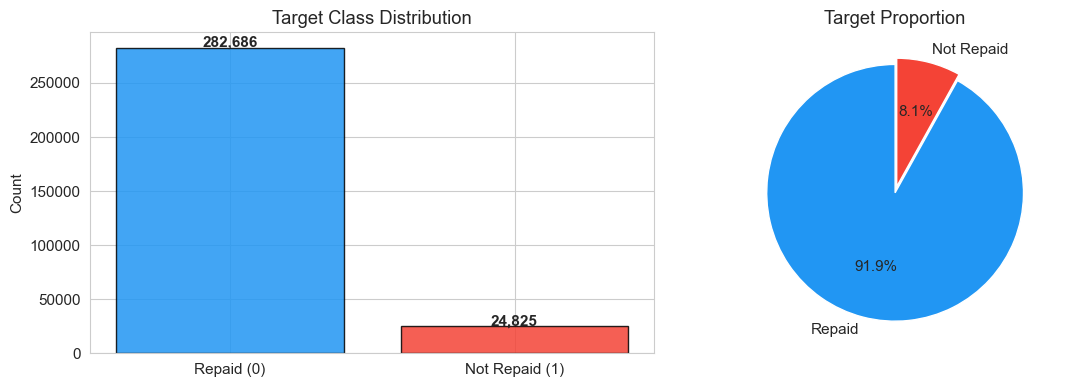


=> Strong class imbalance: ~91.9% repaid vs ~8.1% not repaid.
=> Accuracy is NOT a good metric here – use AUC-ROC instead.


In [4]:
target_counts = train['TARGET'].value_counts()
target_pct    = train['TARGET'].value_counts(normalize=True) * 100

print('Target distribution:')
print(f'  0 (repaid):     {target_counts[0]:,} ({target_pct[0]:.1f}%)')
print(f'  1 (not repaid): {target_counts[1]:,} ({target_pct[1]:.1f}%)')
print(f'  Class imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Repaid (0)', 'Not Repaid (1)'], target_counts.values,
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='black')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Repaid', 'Not Repaid'],
            colors=['#2196F3', '#F44336'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Target Proportion')
plt.tight_layout()
plt.show()

print('\n=> Strong class imbalance: ~91.9% repaid vs ~8.1% not repaid.')
print('=> Accuracy is NOT a good metric here – use AUC-ROC instead.')

## 3. Missing Values Analysis

In [5]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    miss_pct = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
    print(f'\n{name}: {len(miss)} columns with missing values')
    return result

miss_train = missing_summary(train, 'application_train')
print(miss_train.head(20).to_string())


application_train: 67 columns with missing values
                          Missing Count  Missing %
COMMONAREA_MEDI                  214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_AVG                   214865      69.87
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35
FLOORSMIN_MEDI                   208642      67.85
FLOORSMIN_MODE                   208642      67.85
FLOORSMIN_AVG                    208642      67.85
YEARS_BUILD_MODE                 204488      66.50
YEARS_BUILD_MEDI                 204488      66.50
YEARS_BUILD_AVG                  204488      66.50
OWN_CAR_AGE                      202929      65.99
LANDAREA_AVG                   

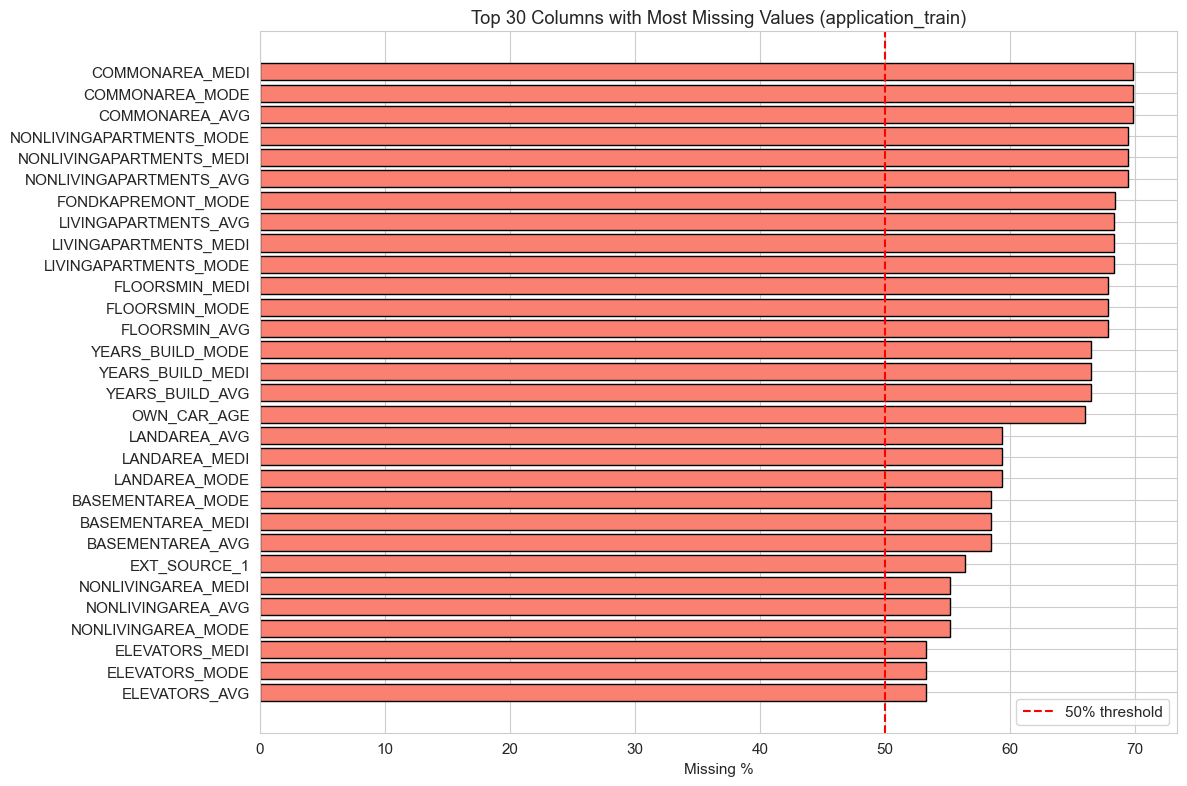

Columns with >50% missing: 41
=> LightGBM handles missing values natively – no imputation required.


In [6]:
# Top 30 missing columns
top_miss = miss_train.head(30)
plt.figure(figsize=(12, 8))
plt.barh(top_miss.index[::-1], top_miss['Missing %'][::-1], color='salmon', edgecolor='black')
plt.xlabel('Missing %')
plt.title('Top 30 Columns with Most Missing Values (application_train)')
plt.axvline(50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

high_miss = miss_train[miss_train['Missing %'] > 50]
print(f'Columns with >50% missing: {len(high_miss)}')
print('=> LightGBM handles missing values natively – no imputation required.')

## 4. Numerical Features Analysis

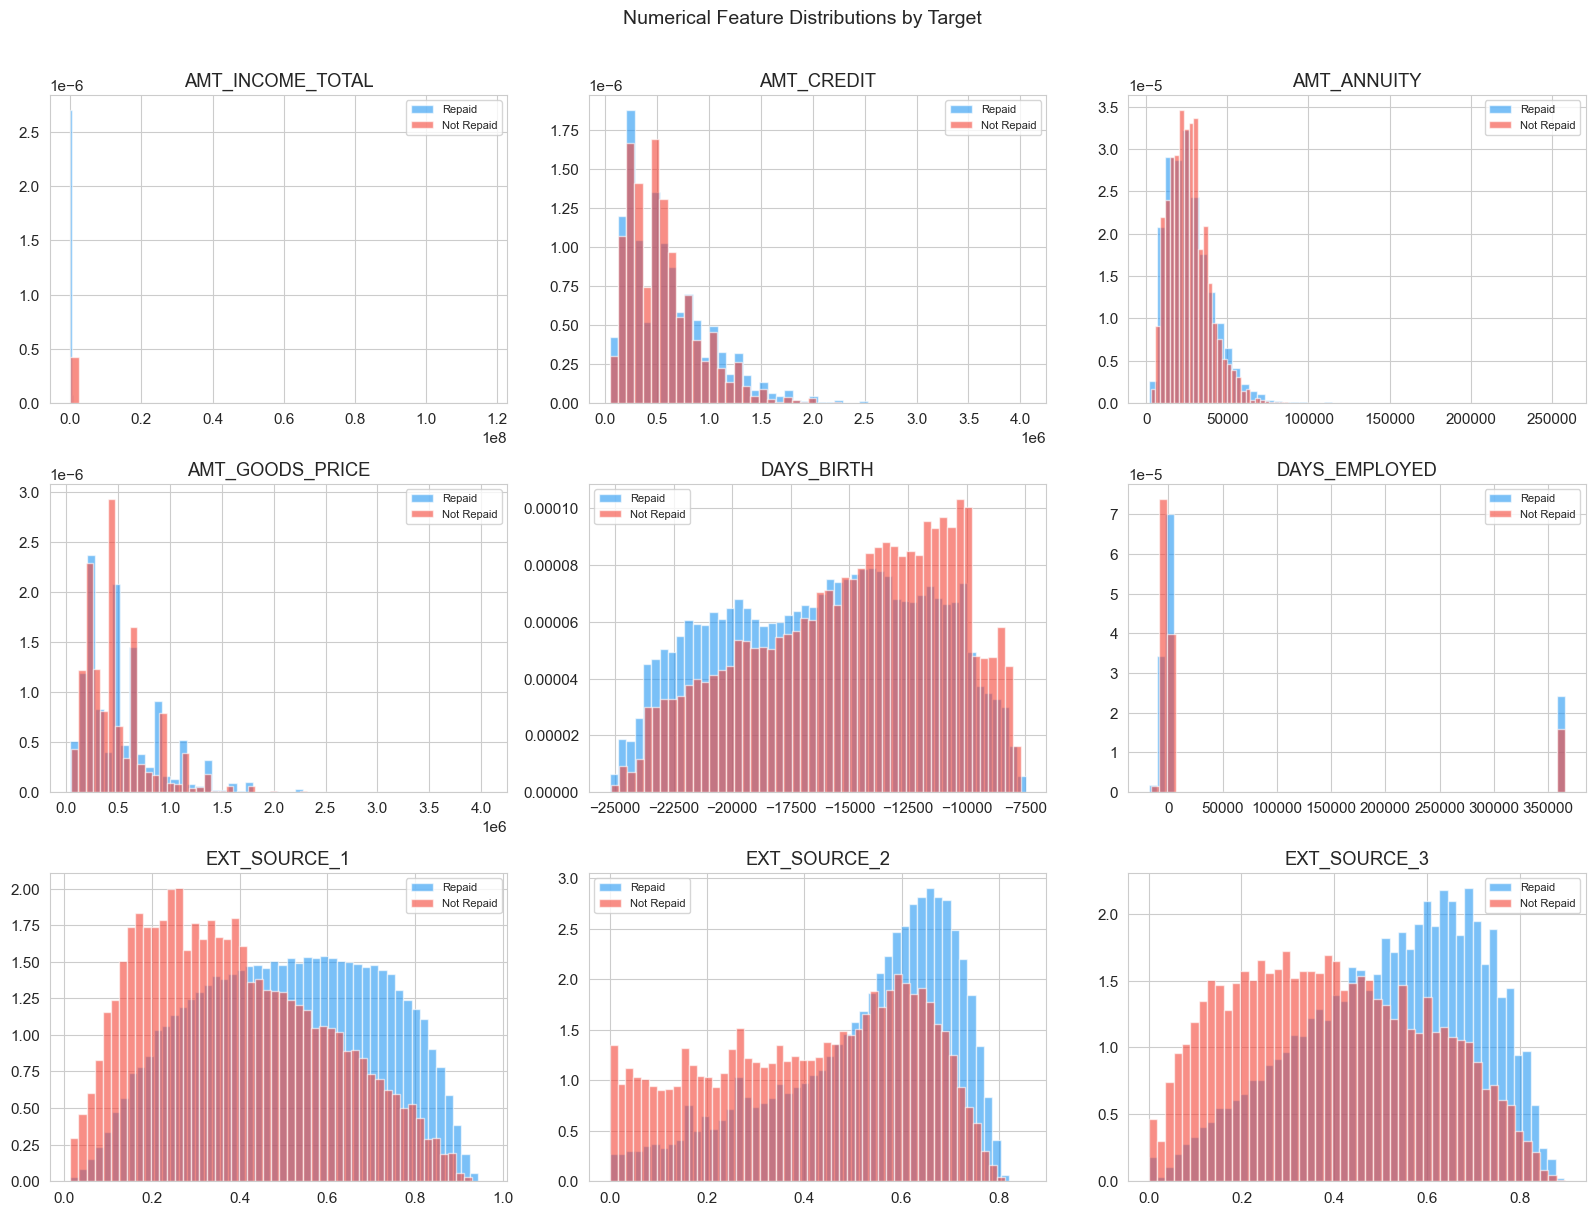

In [7]:
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), num_cols):
    d0 = train.loc[train['TARGET'] == 0, col].dropna()
    d1 = train.loc[train['TARGET'] == 1, col].dropna()
    ax.hist(d0, bins=50, alpha=0.6, color='#2196F3', label='Repaid', density=True)
    ax.hist(d1, bins=50, alpha=0.6, color='#F44336', label='Not Repaid', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Numerical Feature Distributions by Target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

DAYS_EMPLOYED unique anomalous value count:
  365243 appears 55,374 times
  That is 18.0% of the training set


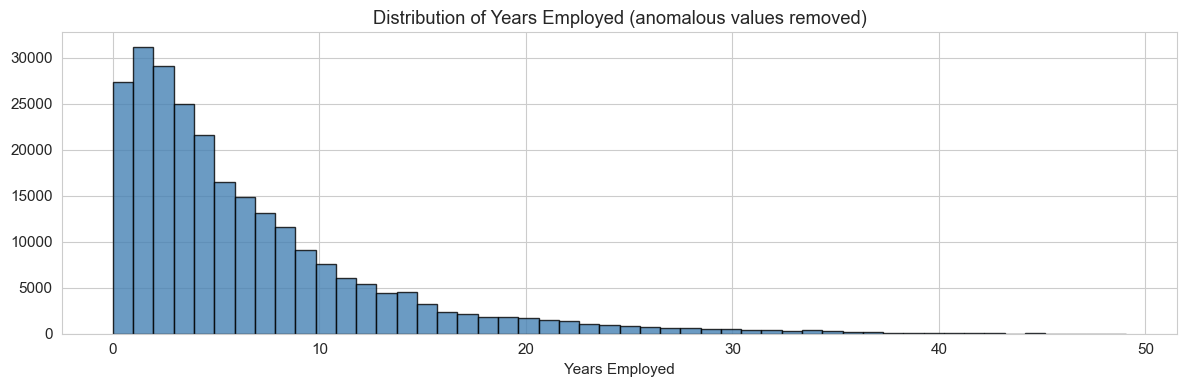

=> We create a binary flag DAYS_EMPLOYED_ANOM and replace 365243 with NaN.


In [8]:
# DAYS_EMPLOYED anomaly: value 365243 represents 'not employed'
print('DAYS_EMPLOYED unique anomalous value count:')
print(f"  365243 appears {(train['DAYS_EMPLOYED'] == 365243).sum():,} times")
print(f"  That is {(train['DAYS_EMPLOYED'] == 365243).mean()*100:.1f}% of the training set")

# Distribution after removing anomaly
valid_emp = train.loc[train['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED']
plt.figure(figsize=(12, 4))
plt.hist(valid_emp / -365, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Years Employed')
plt.title('Distribution of Years Employed (anomalous values removed)')
plt.tight_layout()
plt.show()
print('=> We create a binary flag DAYS_EMPLOYED_ANOM and replace 365243 with NaN.')

## 5. External Source Scores (Key Predictors)

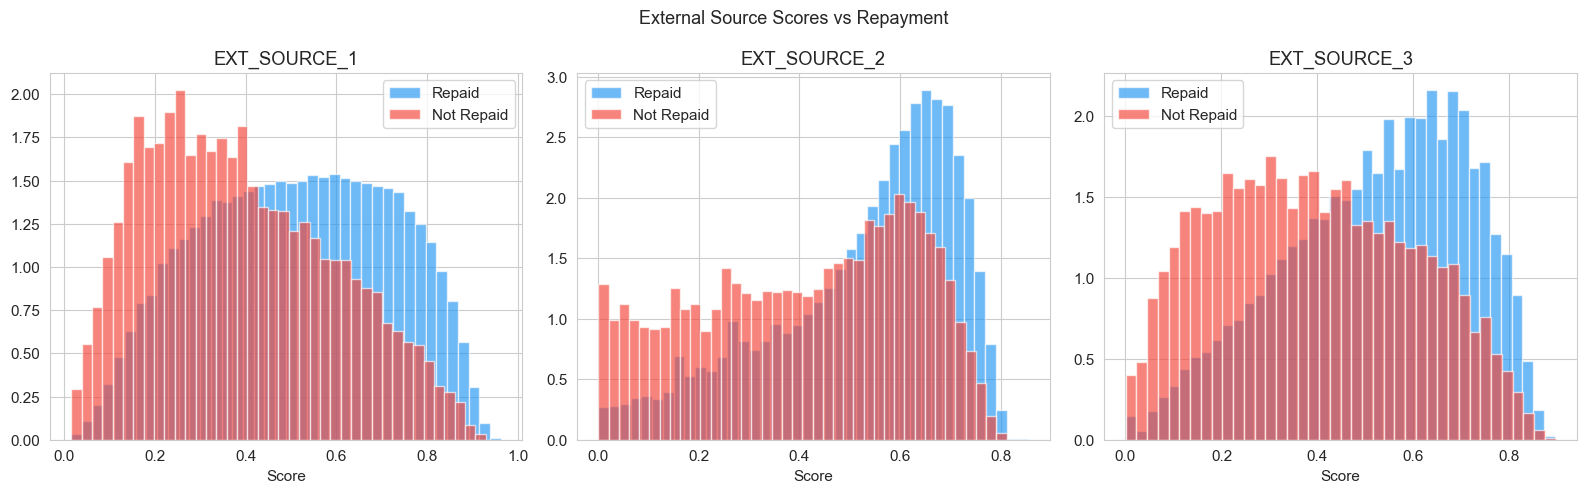

EXT_SOURCE_1 correlation with TARGET: -0.1553
EXT_SOURCE_2 correlation with TARGET: -0.1605
EXT_SOURCE_3 correlation with TARGET: -0.1789
=> EXT_SOURCE scores are strong negative predictors of not repaying.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for target, color, label in [(0, '#2196F3', 'Repaid'), (1, '#F44336', 'Not Repaid')]:
        vals = train.loc[train['TARGET'] == target, col].dropna()
        ax.hist(vals, bins=40, alpha=0.65, color=color, label=label, density=True)
    ax.set_title(col)
    ax.legend()
    ax.set_xlabel('Score')
plt.suptitle('External Source Scores vs Repayment', fontsize=13)
plt.tight_layout()
plt.show()

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    corr = train[[col, 'TARGET']].dropna().corr().iloc[0, 1]
    print(f'{col} correlation with TARGET: {corr:.4f}')
print('=> EXT_SOURCE scores are strong negative predictors of not repaying.')

## 6. Categorical Features Analysis

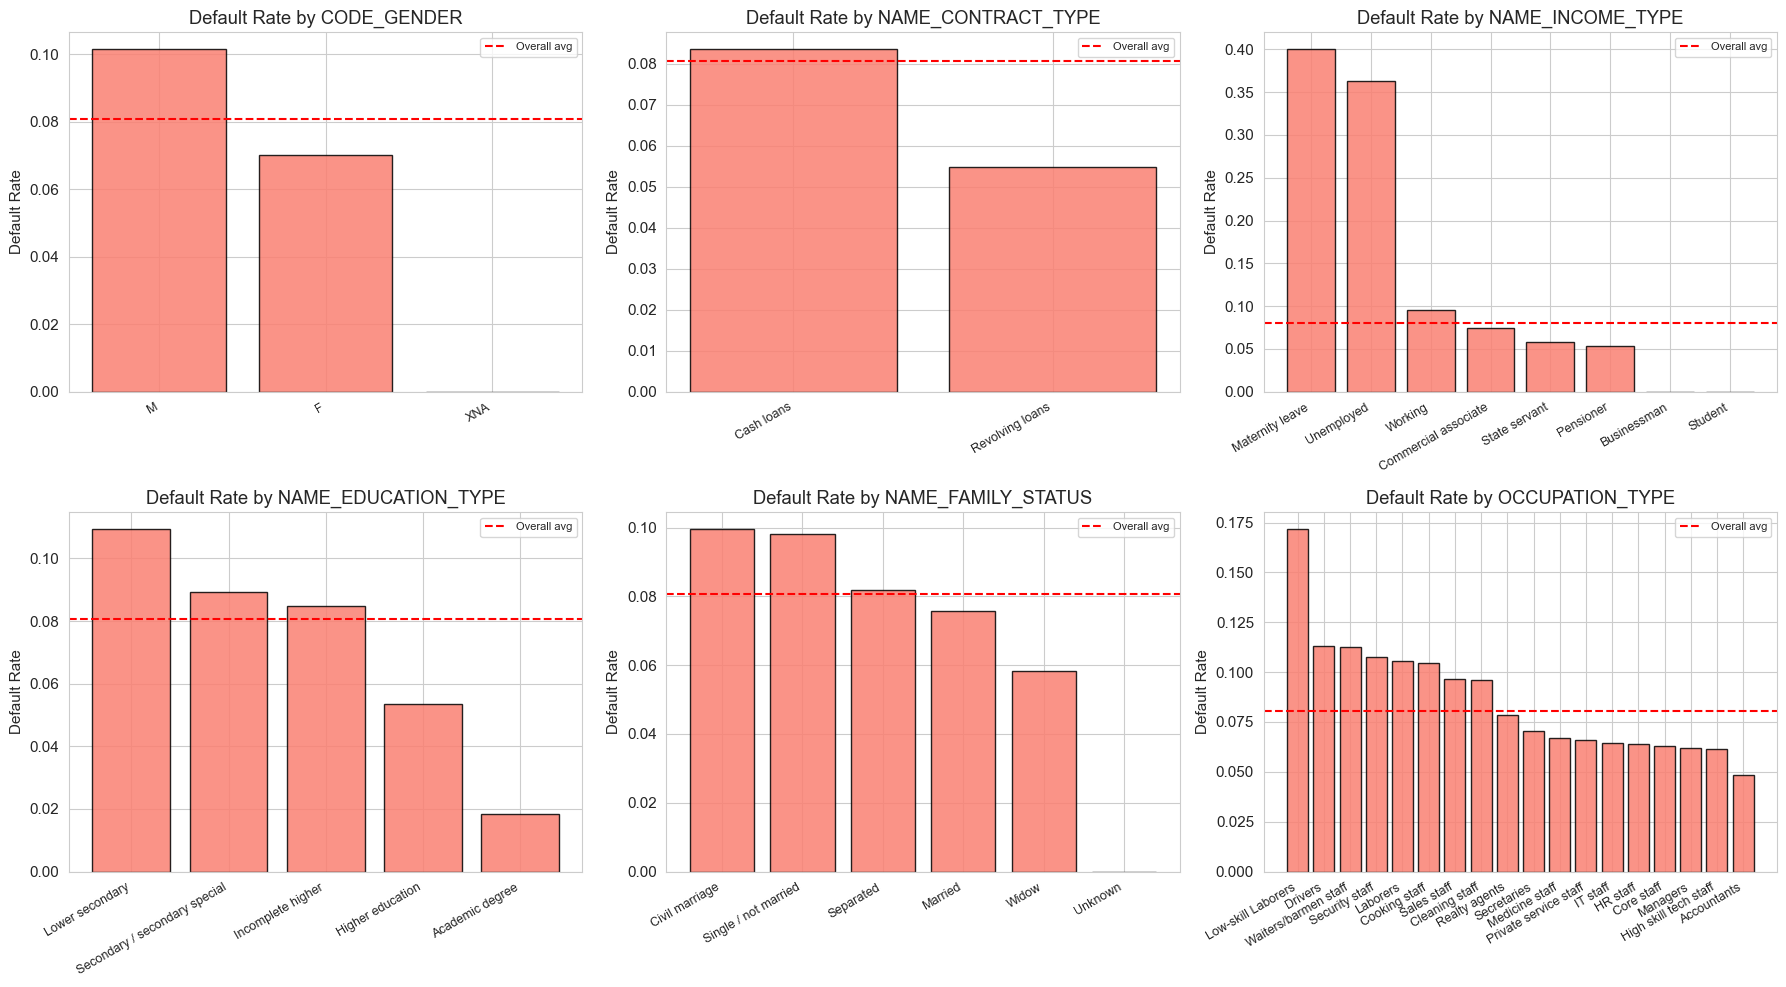

In [10]:
cat_cols = ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE',
            'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'OCCUPATION_TYPE']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    default_rate = train.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    bars = ax.bar(range(len(default_rate)), default_rate.values,
                  color='salmon', edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(default_rate)))
    ax.set_xticklabels(default_rate.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate')
    ax.axhline(train['TARGET'].mean(), color='red', linestyle='--', label='Overall avg')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

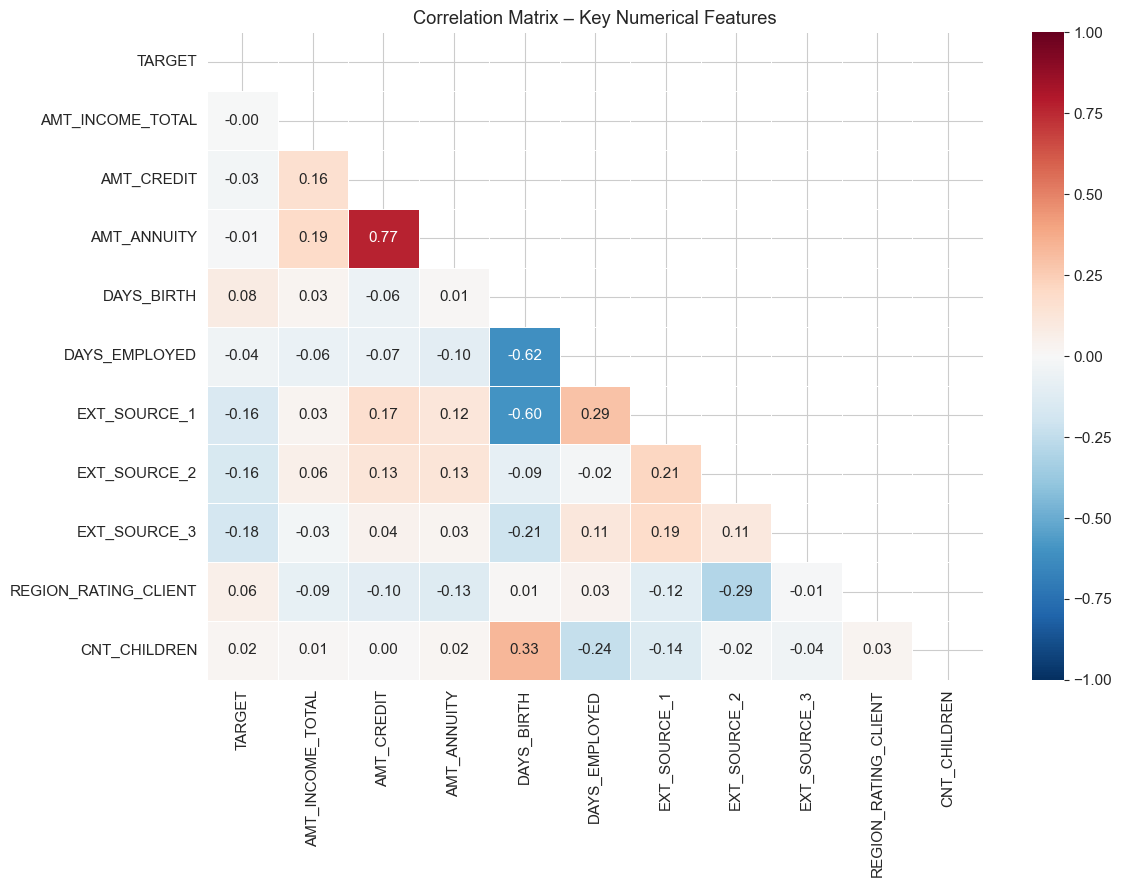

Correlation with TARGET:
EXT_SOURCE_3           -0.178919
EXT_SOURCE_2           -0.160472
EXT_SOURCE_1           -0.155317
DAYS_EMPLOYED          -0.044932
AMT_CREDIT             -0.030369
AMT_ANNUITY            -0.012817
AMT_INCOME_TOTAL       -0.003982
CNT_CHILDREN            0.019187
REGION_RATING_CLIENT    0.058899
DAYS_BIRTH              0.078239


In [11]:
corr_cols = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
             'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
             'REGION_RATING_CLIENT', 'CNT_CHILDREN']

corr_matrix = train[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix – Key Numerical Features')
plt.tight_layout()
plt.show()

target_corr = train[corr_cols].corr()['TARGET'].drop('TARGET').sort_values()
print('Correlation with TARGET:')
print(target_corr.to_string())

## 8. Bureau Data Analysis

Bureau shape: (1716428, 17)
Unique clients in bureau: 305,811
Clients in train:         307,511
Coverage: 99.4%

Loans per client – Mean: 5.6, Max: 116


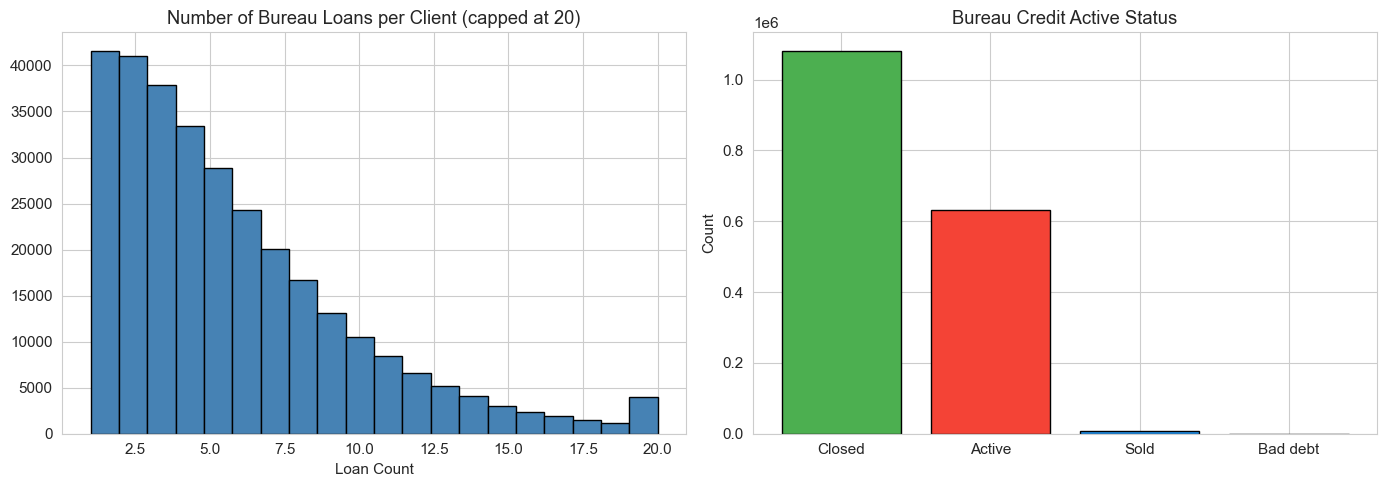

In [12]:
print(f'Bureau shape: {bureau.shape}')
print(f'Unique clients in bureau: {bureau["SK_ID_CURR"].nunique():,}')
print(f'Clients in train:         {train["SK_ID_CURR"].nunique():,}')
print(f'Coverage: {bureau["SK_ID_CURR"].nunique() / train["SK_ID_CURR"].nunique() * 100:.1f}%')

# Loans per client
loans_per_client = bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count()
print(f'\nLoans per client – Mean: {loans_per_client.mean():.1f}, Max: {loans_per_client.max()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(loans_per_client.clip(upper=20), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Number of Bureau Loans per Client (capped at 20)')
axes[0].set_xlabel('Loan Count')

credit_active = bureau['CREDIT_ACTIVE'].value_counts()
axes[1].bar(credit_active.index, credit_active.values, color=['#4CAF50','#F44336','#2196F3','#FF9800'], edgecolor='black')
axes[1].set_title('Bureau Credit Active Status')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

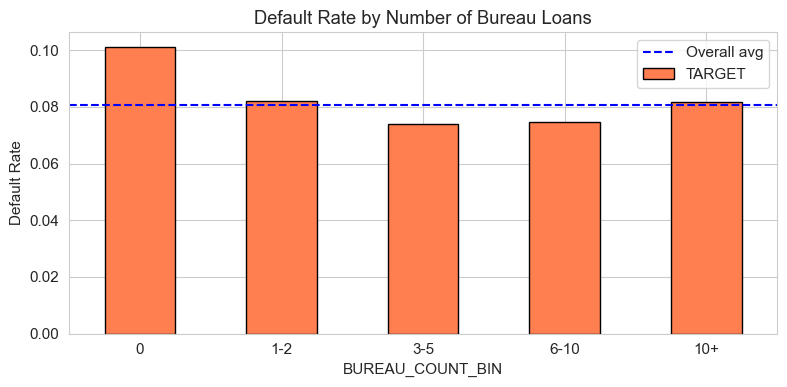

=> Clients with more bureau loans tend to have higher default rates.


In [13]:
# Bureau default rate by number of bureau loans
bureau_count = bureau.groupby('SK_ID_CURR').size().rename('BUREAU_COUNT')
train_with_bureau = train[['SK_ID_CURR', 'TARGET']].merge(bureau_count, on='SK_ID_CURR', how='left')
train_with_bureau['BUREAU_COUNT_BIN'] = pd.cut(train_with_bureau['BUREAU_COUNT'].fillna(0),
                                                 bins=[-1, 0, 2, 5, 10, 100], labels=['0','1-2','3-5','6-10','10+'])

default_by_bureau = train_with_bureau.groupby('BUREAU_COUNT_BIN')['TARGET'].mean()

plt.figure(figsize=(8, 4))
default_by_bureau.plot(kind='bar', color='coral', edgecolor='black', rot=0)
plt.axhline(train['TARGET'].mean(), color='blue', linestyle='--', label='Overall avg')
plt.title('Default Rate by Number of Bureau Loans')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()
print('=> Clients with more bureau loans tend to have higher default rates.')

## 9. Bureau Balance (DPD – Days Past Due)

Bureau balance shape: (27299925, 3)


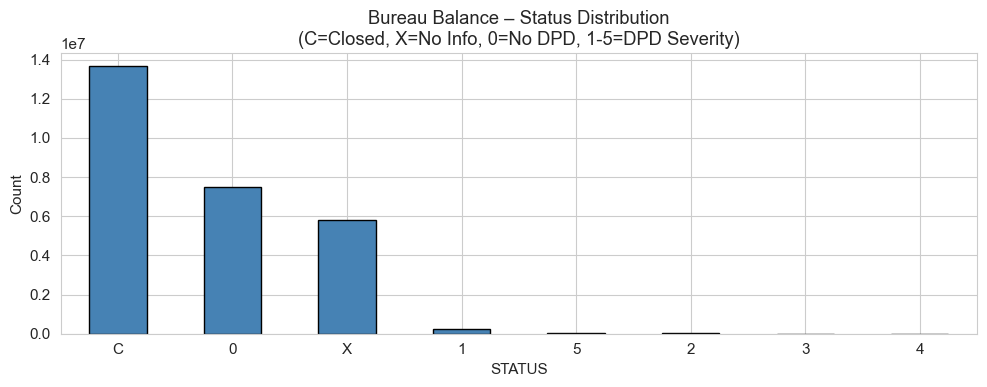

Avg DPD rate per bureau credit: 0.0138
=> Create DPD ratio as aggregated feature per client.


In [14]:
print(f'Bureau balance shape: {bureau_balance.shape}')

status_counts = bureau_balance['STATUS'].value_counts()
plt.figure(figsize=(10, 4))
status_counts.plot(kind='bar', color='steelblue', edgecolor='black', rot=0)
plt.title('Bureau Balance – Status Distribution\n(C=Closed, X=No Info, 0=No DPD, 1-5=DPD Severity)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# DPD rate per bureau credit
bureau_balance['IS_DPD'] = bureau_balance['STATUS'].isin(['1','2','3','4','5']).astype(int)
dpd_by_bureau = bureau_balance.groupby('SK_ID_BUREAU')['IS_DPD'].mean()
print(f'Avg DPD rate per bureau credit: {dpd_by_bureau.mean():.4f}')
print('=> Create DPD ratio as aggregated feature per client.')

## 10. Previous Applications Analysis

Previous applications shape: (1670214, 37)
Unique clients: 338,857


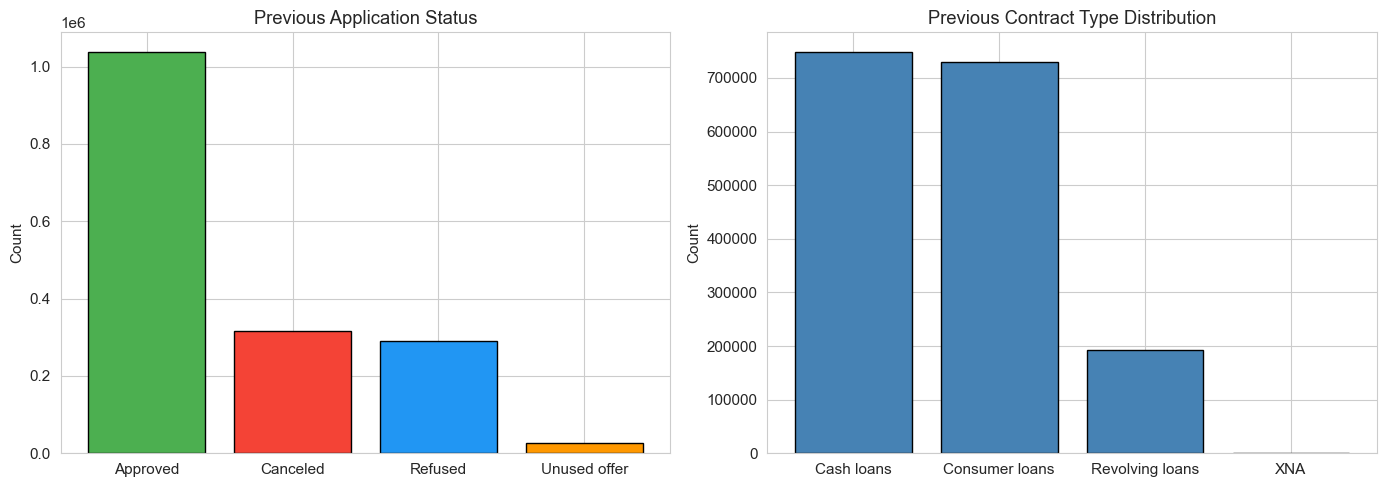

In [15]:
print(f'Previous applications shape: {prev.shape}')
print(f'Unique clients: {prev["SK_ID_CURR"].nunique():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

contract_status = prev['NAME_CONTRACT_STATUS'].value_counts()
axes[0].bar(contract_status.index, contract_status.values,
            color=['#4CAF50','#F44336','#2196F3','#FF9800'], edgecolor='black')
axes[0].set_title('Previous Application Status')
axes[0].set_ylabel('Count')

contract_type = prev['NAME_CONTRACT_TYPE'].value_counts()
axes[1].bar(contract_type.index, contract_type.values, color='steelblue', edgecolor='black')
axes[1].set_title('Previous Contract Type Distribution')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

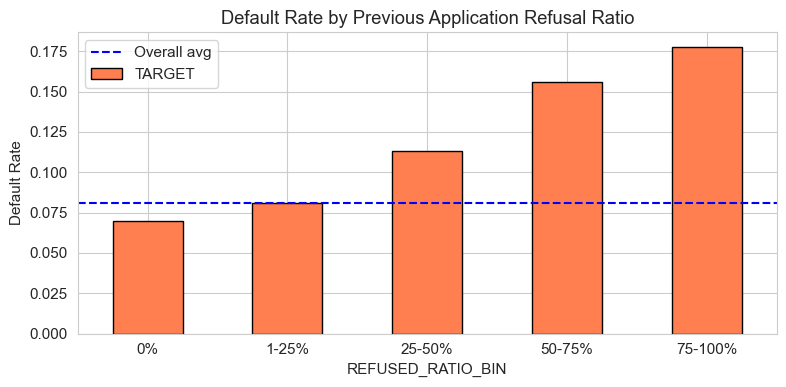

=> Higher refusal ratio strongly correlates with default.


In [16]:
# Refusal ratio vs default rate
refused_ratio = (
    prev.groupby('SK_ID_CURR')['NAME_CONTRACT_STATUS']
    .apply(lambda x: (x == 'Refused').sum() / len(x))
    .rename('REFUSED_RATIO')
)
train_prev = train[['SK_ID_CURR', 'TARGET']].merge(refused_ratio, on='SK_ID_CURR', how='left')
train_prev['REFUSED_RATIO_BIN'] = pd.cut(train_prev['REFUSED_RATIO'].fillna(0),
                                           bins=[-0.01, 0, 0.25, 0.5, 0.75, 1.01],
                                           labels=['0%','1-25%','25-50%','50-75%','75-100%'])

default_by_refused = train_prev.groupby('REFUSED_RATIO_BIN')['TARGET'].mean()

plt.figure(figsize=(8, 4))
default_by_refused.plot(kind='bar', color='coral', edgecolor='black', rot=0)
plt.axhline(train['TARGET'].mean(), color='blue', linestyle='--', label='Overall avg')
plt.title('Default Rate by Previous Application Refusal Ratio')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()
print('=> Higher refusal ratio strongly correlates with default.')

## 11. POS CASH Balance Analysis

POS CASH shape: (10001358, 8)


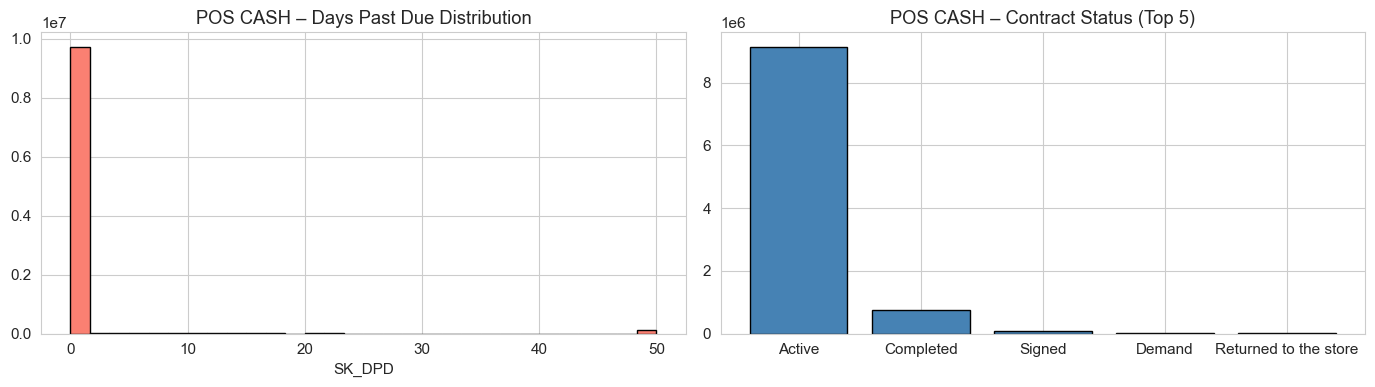

Correlation of mean POS DPD with TARGET: 0.0054


In [17]:
print(f'POS CASH shape: {pos.shape}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pos['SK_DPD'].clip(upper=50), bins=30, color='salmon', edgecolor='black')
axes[0].set_title('POS CASH – Days Past Due Distribution')
axes[0].set_xlabel('SK_DPD')

pos_status = pos['NAME_CONTRACT_STATUS'].value_counts().head(5)
axes[1].bar(pos_status.index, pos_status.values, color='steelblue', edgecolor='black')
axes[1].set_title('POS CASH – Contract Status (Top 5)')
plt.tight_layout()
plt.show()

# DPD > 0 per client vs default
dpd_client = pos.groupby('SK_ID_CURR')['SK_DPD'].mean().rename('POS_DPD_MEAN')
train_pos = train[['SK_ID_CURR','TARGET']].merge(dpd_client, on='SK_ID_CURR', how='left')
print(f'Correlation of mean POS DPD with TARGET: {train_pos[["POS_DPD_MEAN","TARGET"]].corr().iloc[0,1]:.4f}')

## 12. Credit Card Balance Analysis

Credit card shape: (3840312, 23)


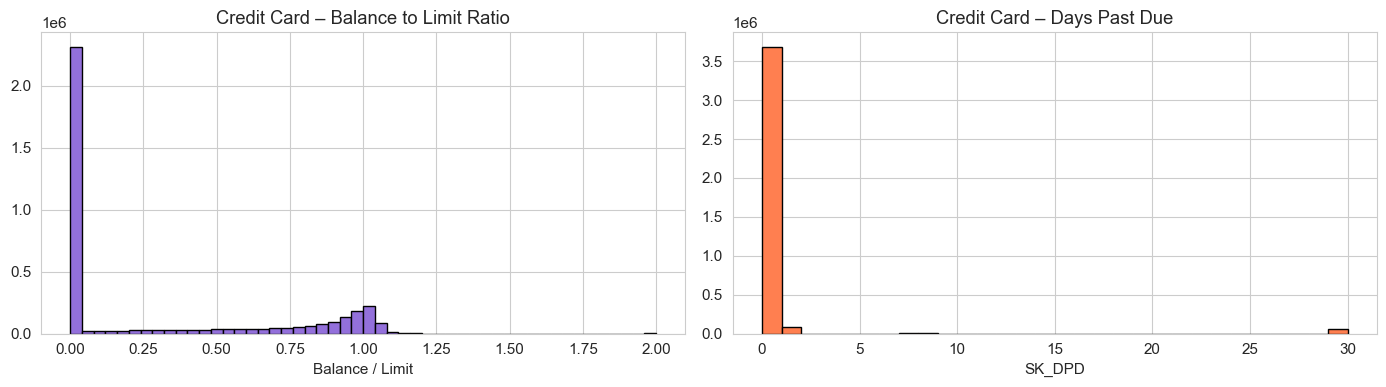

Correlation of CC DPD mean with TARGET: -0.0032


In [18]:
print(f'Credit card shape: {cc.shape}')

cc['BALANCE_LIMIT_RATIO'] = cc['AMT_BALANCE'] / (cc['AMT_CREDIT_LIMIT_ACTUAL'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(cc['BALANCE_LIMIT_RATIO'].clip(0, 2), bins=50, color='mediumpurple', edgecolor='black')
axes[0].set_title('Credit Card – Balance to Limit Ratio')
axes[0].set_xlabel('Balance / Limit')

axes[1].hist(cc['SK_DPD'].clip(upper=30), bins=30, color='coral', edgecolor='black')
axes[1].set_title('Credit Card – Days Past Due')
axes[1].set_xlabel('SK_DPD')
plt.tight_layout()
plt.show()

cc_dpd = cc.groupby('SK_ID_CURR')['SK_DPD'].mean().rename('CC_DPD_MEAN')
train_cc = train[['SK_ID_CURR','TARGET']].merge(cc_dpd, on='SK_ID_CURR', how='left')
print(f'Correlation of CC DPD mean with TARGET: {train_cc[["CC_DPD_MEAN","TARGET"]].corr().iloc[0,1]:.4f}')

## 13. Installments Payments Analysis

Installments shape: (13605401, 8)


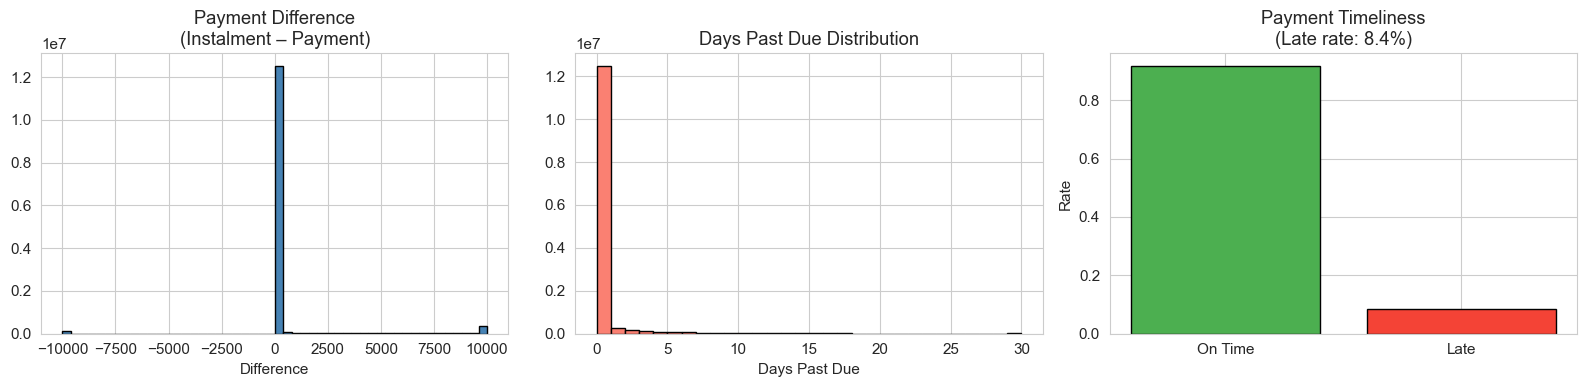

Correlation of late payment ratio with TARGET: 0.0700
=> Late payment history is a strong predictor of future default.


In [19]:
print(f'Installments shape: {installments.shape}')

installments['PAYMENT_DIFF'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
installments['DAYS_PAST_DUE'] = (installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']).clip(lower=0)
installments['LATE_PAYMENT'] = (installments['DAYS_PAST_DUE'] > 0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(installments['PAYMENT_DIFF'].clip(-10000, 10000), bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Payment Difference\n(Instalment – Payment)')
axes[0].set_xlabel('Difference')

axes[1].hist(installments['DAYS_PAST_DUE'].clip(upper=30), bins=30, color='salmon', edgecolor='black')
axes[1].set_title('Days Past Due Distribution')
axes[1].set_xlabel('Days Past Due')

late_rate = installments['LATE_PAYMENT'].mean()
axes[2].bar(['On Time', 'Late'], [1 - late_rate, late_rate],
            color=['#4CAF50', '#F44336'], edgecolor='black')
axes[2].set_title(f'Payment Timeliness\n(Late rate: {late_rate:.1%})')
axes[2].set_ylabel('Rate')
plt.tight_layout()
plt.show()

# Late payment ratio vs default
late_client = installments.groupby('SK_ID_CURR')['LATE_PAYMENT'].mean().rename('LATE_RATIO')
train_inst = train[['SK_ID_CURR','TARGET']].merge(late_client, on='SK_ID_CURR', how='left')
print(f'Correlation of late payment ratio with TARGET: {train_inst[["LATE_RATIO","TARGET"]].corr().iloc[0,1]:.4f}')
print('=> Late payment history is a strong predictor of future default.')

## 14. Derived Feature Insights

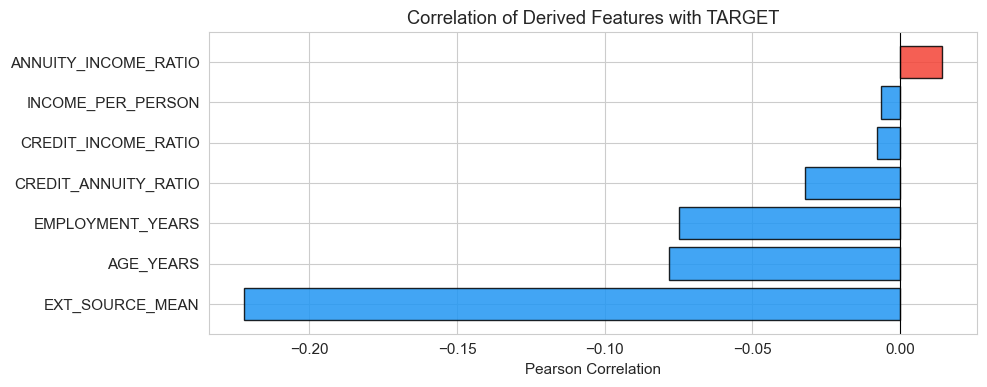

Correlations:
 EXT_SOURCE_MEAN        -0.222052
AGE_YEARS              -0.078239
EMPLOYMENT_YEARS       -0.074958
CREDIT_ANNUITY_RATIO   -0.032101
CREDIT_INCOME_RATIO    -0.007727
INCOME_PER_PERSON      -0.006441
ANNUITY_INCOME_RATIO    0.014265


In [20]:
# Key derived features and their correlation with TARGET
df_feat = train.copy()
df_feat['DAYS_EMPLOYED'] = df_feat['DAYS_EMPLOYED'].replace(365243, np.nan)
df_feat['CREDIT_INCOME_RATIO']  = df_feat['AMT_CREDIT'] / (df_feat['AMT_INCOME_TOTAL'] + 1)
df_feat['ANNUITY_INCOME_RATIO'] = df_feat['AMT_ANNUITY'] / (df_feat['AMT_INCOME_TOTAL'] + 1)
df_feat['CREDIT_ANNUITY_RATIO'] = df_feat['AMT_CREDIT'] / (df_feat['AMT_ANNUITY'] + 1)
df_feat['AGE_YEARS']            = -df_feat['DAYS_BIRTH'] / 365
df_feat['EMPLOYMENT_YEARS']     = -df_feat['DAYS_EMPLOYED'] / 365
df_feat['INCOME_PER_PERSON']    = df_feat['AMT_INCOME_TOTAL'] / (df_feat['CNT_FAM_MEMBERS'] + 1)
df_feat['EXT_SOURCE_MEAN']      = df_feat[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)

derived = ['CREDIT_INCOME_RATIO','ANNUITY_INCOME_RATIO','CREDIT_ANNUITY_RATIO',
           'AGE_YEARS','EMPLOYMENT_YEARS','INCOME_PER_PERSON','EXT_SOURCE_MEAN']

corrs = df_feat[derived + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()
plt.figure(figsize=(10, 4))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corrs.values]
plt.barh(corrs.index, corrs.values, color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Derived Features with TARGET')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Correlations:\n', corrs.to_string())

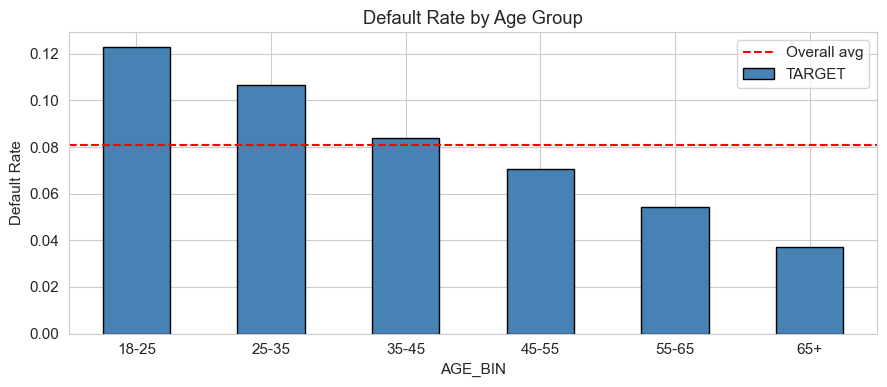

=> Younger clients (18-35) have significantly higher default rates.


In [21]:
# Age vs default rate
df_feat['AGE_BIN'] = pd.cut(df_feat['AGE_YEARS'], bins=[18, 25, 35, 45, 55, 65, 100],
                             labels=['18-25','25-35','35-45','45-55','55-65','65+'])
default_by_age = df_feat.groupby('AGE_BIN')['TARGET'].mean()

plt.figure(figsize=(9, 4))
default_by_age.plot(kind='bar', color='steelblue', edgecolor='black', rot=0)
plt.axhline(train['TARGET'].mean(), color='red', linestyle='--', label='Overall avg')
plt.title('Default Rate by Age Group')
plt.ylabel('Default Rate')
plt.legend()
plt.tight_layout()
plt.show()
print('=> Younger clients (18-35) have significantly higher default rates.')

## 15. Key Insights Summary

### Findings
1. **Strong class imbalance**: 91.9% repaid vs 8.1% not repaid → **AUC-ROC** is the right metric, not accuracy.
2. **EXT_SOURCE scores** (1, 2, 3) are the strongest individual predictors of not repaying (negative correlation).
3. **DAYS_EMPLOYED anomaly**: 365,243 encodes unemployment; replaced with NaN + binary flag.
4. **Younger clients** (18-35) do not repay at significantly higher rates.
5. **Bureau data**: Clients with more past loans and higher DPD rates are more likely not to repay.
6. **Previous application refusals**: High refusal ratio strongly predicts not repaying.
7. **Late payment history** in installments is a strong predictor.
8. **Credit-to-income ratio** and **annuity-to-income ratio** capture repayment burden.

### Feature Engineering Decisions
- Aggregate all supplementary tables (bureau, previous_app, POS, CC, installments) by `SK_ID_CURR`
- Create ratio features: credit/income, annuity/income, credit/annuity
- Combine EXT_SOURCE scores: mean, std, product, pairwise products
- Create behavioral features: DPD rates, late payment ratios
- Handle missing values: LightGBM handles NaN natively

### Model Choice
- **LightGBM**: Best suited for tabular data with missing values, fast training, handles class imbalance, provides native feature importance
- **5-fold stratified cross-validation** to get robust AUC estimate
- **Early stopping** to prevent overfitting